# Term Project — LIN28A: Translation vs Stability separation

**Hypothesis.** Cho et al. 2012 conclude LIN28A acts as a *translational* suppressor of its bound mRNAs.  However, the paper does not quantitatively separate translation-mediated derepression (ΔTE) from stability-mediated derepression (ΔRNA) at the per-transcript level.  This project asks: for LIN28A-bound mRNAs, does derepression come from (a) ΔTE alone, (b) ΔRNA alone, (c) both — and do mRNA features (length, GC content, subcellular localization) distinguish the three mechanism groups?

**Plan.**
- **W4** — compute ΔRNA, ΔTE; define LIN28A bound genes by CLIP density; partition bound genes into mechanism groups.
- **W5** — compare mRNA features across groups with non-parametric tests + multiple-testing correction.
- **W6** — integrated figure; sanity-check with unbound controls; write-up.

## W4 — Data loading

Inputs (all from 1주차):
- `read-counts.txt` — featureCounts output, 6 BAMs: CLIP-35L33G, RNA-control, RNA-siLin28a, RNA-siLuc, RPF-siLin28a, RPF-siLuc.
- `mouselocalization.txt` — gene_id → subcellular localization.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)

counts = pd.read_csv('read-counts.txt', sep='\t', skiprows=1)
counts.columns = [c.replace('.bam', '') for c in counts.columns]
print('shape:', counts.shape)
counts.head()

shape: (55359, 12)


,Geneid,Chr,Start,End,Strand,Length,CLIP-35L33G,RNA-control,RNA-siLin28a,RNA-siLuc,RPF-siLin28a,RPF-siLuc
0,ENSMUSG00000102693.2,chr1,3143476,3144545,+,1070,0,0,0,0,0,0
1,ENSMUSG00000064842.3,chr1,3172239,3172348,+,110,0,0,0,0,0,0
2,ENSMUSG00000051951.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1,3276124;3276746;3283662;3283832;3284705;349192...,3277540;3277540;3285855;3286567;3287191;349212...,-;-;-;-;-;-;-,6094,4,1,1,1,0,0
3,ENSMUSG00000102851.2,chr1,3322980,3323459,+,480,3,0,0,0,0,0
4,ENSMUSG00000103377.2,chr1,3435954,3438772,-,2819,0,0,0,0,0,0


## W4-1 — Filtering, normalization, and key metrics

  - **Filter**: 4개 sample (RNA-siLuc, RNA-siLin28a, RPF-siLuc, RPF-siLin28a) 모두에서 count ≥ 10 인 유전자만 — 비표현 유전자에서 ratio가 noisy해지는 것 방지.
  - **CPM normalization**: 라이브러리 크기 차이 보정.
  - **ΔRNA** = log2(RNA_siLin28a / RNA_siLuc) — mRNA level 변화 (stability 대리지표).
  - **ΔTE** = log2((RPF/RNA)_siLin28a / (RPF/RNA)_siLuc) — 진짜 translational regulation.
  - **CLIP binding enrichment** = log2((CLIP_cpm + 1) / (RNA-siLuc_cpm + 1)) — mRNA 풍부도 보정한 LIN28A binding 강도. 단순 CLIP count는 긴 유전자/풍부한 유전자에 biased.

In [10]:
# Filter to expressed genes (count >= 10 in all 4 RNA/RPF samples)
keep = ((counts['RNA-siLuc']    >= 10) &
        (counts['RNA-siLin28a'] >= 10) &
        (counts['RPF-siLuc']    >= 10) &
        (counts['RPF-siLin28a'] >= 10))

sample_cols = ['RNA-siLuc', 'RNA-siLin28a', 'RPF-siLuc', 'RPF-siLin28a', 'CLIP-35L33G']
df = counts.loc[keep, ['Geneid', 'Length'] + sample_cols].copy()
df['Geneid'] = df['Geneid'].str.split('.').str[0]   # ENSMUSG... version 제거 (localization 매칭용)
print(f'expressed genes: {len(df)}')

# CPM normalization (use full table library size, not filtered)
libsize = counts[sample_cols].sum()
for c in sample_cols:
    df[c + '_cpm'] = df[c] / libsize[c] * 1e6

# ΔRNA: stability proxy
df['dRNA'] = np.log2(df['RNA-siLin28a_cpm'] / df['RNA-siLuc_cpm'])

# ΔTE: translational regulation
df['TE_siLuc']    = df['RPF-siLuc_cpm']    / df['RNA-siLuc_cpm']
df['TE_siLin28a'] = df['RPF-siLin28a_cpm'] / df['RNA-siLin28a_cpm']
df['dTE'] = np.log2(df['TE_siLin28a'] / df['TE_siLuc'])

# LIN28A binding enrichment per mRNA (controls for gene expression)
PSEUDO = 1
df['CLIP_enrichment'] = np.log2(
    (df['CLIP-35L33G_cpm'] + PSEUDO) / (df['RNA-siLuc_cpm'] + PSEUDO)
)

print(df[['dRNA', 'dTE', 'CLIP_enrichment']].describe().round(3))

expressed genes: 11596
            dRNA        dTE  CLIP_enrichment
count  11596.000  11596.000        11596.000
mean       0.056     -0.195           -0.543
std        0.472      0.660            1.065
min       -3.115     -2.836           -6.659
25%       -0.229     -0.649           -1.249
50%        0.026     -0.218           -0.596
75%        0.309      0.248            0.120
max        2.678      3.564            6.931


## W4-2 — LIN28A bound vs unbound: ΔRNA × ΔTE 분포

  - ΔRNA, ΔTE를 median-center: ribosome profiling 표준. CPM이 글로벌 TE shift를 못 잡아주므로 "대부분 유전자는 변하지 않는다"는 가정 하에 median = 0으로 맞춤.
  우리 관심은 bound vs unbound *상대* 차이.
  - Bound 정의: CLIP_enrichment top quartile (Q3 이상).
  - Unbound 정의: bottom quartile (Q1 이하) — control.
  - Bound가 unbound 대비 (ΔRNA > 0) 또는 (ΔTE > 0) 방향으로 shift돼 있으면 derepression 증거.

binding
mid        5798
bound      2899
unbound    2899
Name: count, dtype: int64


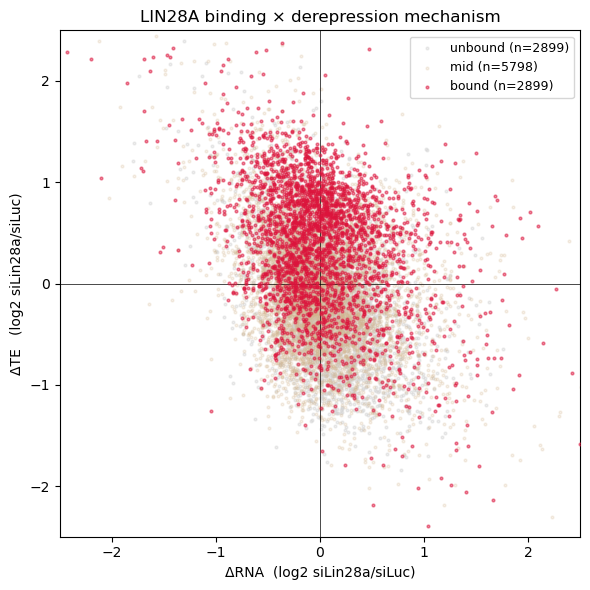

dRNA: bound > unbound,  U = 3641388,  p = 1.00e+00
dTE: bound > unbound,  U = 6498576,  p = 1.17e-284


In [11]:
# Median-center (global library shift 제거)
df['dRNA'] = df['dRNA'] - df['dRNA'].median()
df['dTE']  = df['dTE']  - df['dTE'].median()

# Bound = top quartile, Unbound = bottom quartile, 가운데는 'mid'
q1, q3 = df['CLIP_enrichment'].quantile([0.25, 0.75])
df['binding'] = np.where(df['CLIP_enrichment'] >= q3, 'bound',
                np.where(df['CLIP_enrichment'] <= q1, 'unbound', 'mid'))
print(df['binding'].value_counts())

# Scatter
fig, ax = plt.subplots(figsize=(6, 6))
for label, color, alpha, z in [('unbound', 'lightgrey', 0.4, 1),
                                ('mid',     'tan',       0.2, 2),
                                ('bound',   'crimson',   0.5, 3)]:
    sub = df[df['binding'] == label]
    ax.scatter(sub['dRNA'], sub['dTE'], s=4, alpha=alpha,
                color=color, label=f'{label} (n={len(sub)})', zorder=z)
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('ΔRNA  (log2 siLin28a/siLuc)')
ax.set_ylabel('ΔTE   (log2 siLin28a/siLuc)')
ax.set_title('LIN28A binding × derepression mechanism')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

# Mann-Whitney: bound > unbound? (one-sided)
from scipy.stats import mannwhitneyu
for col in ['dRNA', 'dTE']:
    u, p = mannwhitneyu(df.loc[df.binding=='bound', col],
                        df.loc[df.binding=='unbound', col],
                        alternative='greater')
    print(f'{col}: bound > unbound,  U = {u:.0f},  p = {p:.2e}')

## W4-3 — Bound mRNA mechanism partition

  각 bound mRNA를 derepression 메커니즘으로 분류:
  - **TE-only**: ΔTE 유의↑, ΔRNA 변화 X → translation-mediated
  - **RNA-only**: ΔRNA 유의↑, ΔTE 변화 X → stability-mediated
  - **Both**: 둘 다 ↑
  - **Opposite**: 음 방향 — secondary effects (let-7 등)
  - **No change**: noise 수준

  **Threshold**: unbound 분포의 95% 백분위수(|dRNA|, |dTE|)를 noise floor로.
  Replicate가 없어서 per-gene 통계 대신 unbound를 background null로 사용 — principled & data-driven.

dRNA threshold: ±0.902
dTE  threshold: ±1.227

Bound mRNA mechanism partition:
mechanism
No change    2488
TE-only       164
RNA-only      137
Opposite      108
Both            2
Name: count, dtype: int64


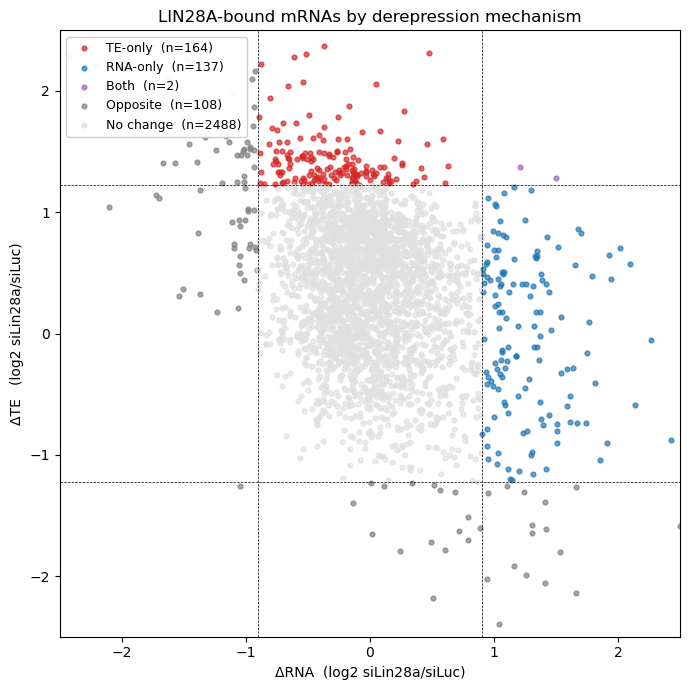

In [12]:
# Noise floor: 95th percentile of |unbound| dRNA, dTE
unbound = df[df['binding'] == 'unbound']
dRNA_thresh = np.percentile(unbound['dRNA'].abs(), 95)
dTE_thresh  = np.percentile(unbound['dTE'].abs(),  95)
print(f'dRNA threshold: ±{dRNA_thresh:.3f}')
print(f'dTE  threshold: ±{dTE_thresh:.3f}')

# Partition bound mRNAs
bound = df[df['binding'] == 'bound'].copy()

def classify(row):
    rna_up = row['dRNA'] >  dRNA_thresh
    rna_dn = row['dRNA'] < -dRNA_thresh
    te_up  = row['dTE']  >  dTE_thresh
    te_dn  = row['dTE']  < -dTE_thresh
    if te_up and not (rna_up or rna_dn):  return 'TE-only'
    if rna_up and not (te_up or te_dn):   return 'RNA-only'
    if te_up and rna_up:                  return 'Both'
    if te_dn or rna_dn:                   return 'Opposite'
    return 'No change'

bound['mechanism'] = bound.apply(classify, axis=1)
print('\nBound mRNA mechanism partition:')
print(bound['mechanism'].value_counts())

# Scatter with mechanism colors
fig, ax = plt.subplots(figsize=(7, 7))
colors = {'TE-only':  '#d62728', 'RNA-only': '#1f77b4',
        'Both':     '#9467bd', 'Opposite': '#7f7f7f',
        'No change':'#e0e0e0'}
for label, color in colors.items():
    sub = bound[bound['mechanism'] == label]
    ax.scatter(sub['dRNA'], sub['dTE'], s=12, alpha=0.7,
                color=color, label=f'{label}  (n={len(sub)})')
ax.axhline( dTE_thresh, color='k', lw=0.5, ls='--')
ax.axhline(-dTE_thresh, color='k', lw=0.5, ls='--')
ax.axvline( dRNA_thresh, color='k', lw=0.5, ls='--')
ax.axvline(-dRNA_thresh, color='k', lw=0.5, ls='--')
ax.set_xlabel('ΔRNA  (log2 siLin28a/siLuc)')
ax.set_ylabel('ΔTE   (log2 siLin28a/siLuc)')
ax.set_title('LIN28A-bound mRNAs by derepression mechanism')
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

 ### W4-3b — Sensitivity to threshold choice

  95% 백분위 threshold는 보수적. 80% 백분위에서도 메커니즘 분포 패턴이 유지되는지 확인.
  - 결론이 robust하면 → main finding 강화
  - 결론이 크게 바뀌면 → finding이 stringency-dependent

In [13]:
# 80% 백분위로 sensitivity check
dRNA_thresh80 = np.percentile(unbound['dRNA'].abs(), 80)
dTE_thresh80  = np.percentile(unbound['dTE'].abs(),  80)
print(f'80%ile thresholds:  dRNA ±{dRNA_thresh80:.3f},  dTE ±{dTE_thresh80:.3f}')

def classify80(row):
    rna_up = row['dRNA'] >  dRNA_thresh80
    rna_dn = row['dRNA'] < -dRNA_thresh80
    te_up  = row['dTE']  >  dTE_thresh80
    te_dn  = row['dTE']  < -dTE_thresh80
    if te_up and not (rna_up or rna_dn):  return 'TE-only'
    if rna_up and not (te_up or te_dn):   return 'RNA-only'
    if te_up and rna_up:                  return 'Both'
    if te_dn or rna_dn:                   return 'Opposite'
    return 'No change'

bound['mechanism_80'] = bound.apply(classify80, axis=1)

# 두 threshold 비교
compare = pd.DataFrame({
    '95%ile (strict)': bound['mechanism'].value_counts(),
    '80%ile (loose)':  bound['mechanism_80'].value_counts(),
}).fillna(0).astype(int)
compare['Δ'] = compare['80%ile (loose)'] - compare['95%ile (strict)']
print('\nMechanism count comparison:')
print(compare)

# 분율도 (그게 더 의미있음)
compare_pct = pd.DataFrame({
    '95%ile': (bound['mechanism'].value_counts(normalize=True) * 100).round(1),
    '80%ile': (bound['mechanism_80'].value_counts(normalize=True) * 100).round(1),
}).fillna(0)
print('\nMechanism share (%):')
print(compare_pct)

80%ile thresholds:  dRNA ±0.511,  dTE ±0.839

Mechanism count comparison:
           95%ile (strict)  80%ile (loose)    Δ
Both                     2              35   33
No change             2488            1628 -860
Opposite               108             434  326
RNA-only               137             320  183
TE-only                164             482  318

Mechanism share (%):
           95%ile  80%ile
Both          0.1     1.2
No change    85.8    56.2
Opposite      3.7    15.0
RNA-only      4.7    11.0
TE-only       5.7    16.6


## Week 5: mRNA feature × Mechanism

  ### W5-1: Localization

  **Hypothesis**: LIN28A bound mRNA의 derepression은 ER-targeted mRNA (integral membrane / secreted)에서 두드러져야 한다. 우리
  mechanism partition에서 TE-only group이 integral membrane으로 enrich되는지 chi-square + Fisher exact로 검정.

  - Main: 95% strict mechanism
  - Robustness: 80% loose mechanism_80
  - Small group (Both n=2) 제외

In [14]:
# W5-1a: Load localization table and check W4 mechanism DataFrame structure

import pandas as pd

loc = pd.read_csv('mouselocalization.txt', sep='\t')
print("=== mouselocalization.txt ===")
print(f"shape: {loc.shape}")
print(f"columns: {list(loc.columns)}")
print(loc.head())
print()
print("type value counts:")
print(loc['type'].value_counts())
print()
print(f"gene_id example: {loc['gene_id'].iloc[0]}  (version suffix? {'yes' if '.' in str(loc['gene_id'].iloc[0]) else 'no'})")  
print()

# W4 mechanism partition DataFrame: bound
# - bound['mechanism']: 95% strict (main)
# - bound['mechanism_80']: 80% loose (robustness)
print(f"=== W4 bound DataFrame: {bound.shape} ===")
print(f"95% mechanism: {dict(bound['mechanism'].value_counts())}")

=== mouselocalization.txt ===
shape: (9523, 3)
columns: ['gene_id', 'Gene names', 'type']
              gene_id            Gene names       type
0  ENSMUSG00000000001                 Gnai3  cytoplasm
1  ENSMUSG00000000028  Cdc45 Cdc45l Cdc45l2    nucleus
2  ENSMUSG00000000049            Apoh B2gp1  cytoplasm
3  ENSMUSG00000000058                  Cav2  cytoplasm
4  ENSMUSG00000000085                 Scmh1    nucleus

type value counts:
type
nucleus              4296
integral membrane    2986
cytoplasm            2241
Name: count, dtype: int64

gene_id example: ENSMUSG00000000001  (version suffix? no)

=== W4 bound DataFrame: (2899, 20) ===
95% mechanism: {'No change': np.int64(2488), 'TE-only': np.int64(164), 'RNA-only': np.int64(137), 'Opposite': np.int64(108), 'Both': np.int64(2)}


In [15]:
# W5-1b-step1: bound DataFrame 구조 확인 (gene_id 위치, version suffix 여부)
print("=== bound DataFrame ===")
print(f"shape: {bound.shape}")
print(f"index name: {bound.index.name}")
print(f"index example: {bound.index[0]}  (type: {type(bound.index[0]).__name__})")
print(f"columns: {list(bound.columns)}")
print()
print("First row:")
print(bound.iloc[0])

=== bound DataFrame ===
shape: (2899, 20)
index name: None
index example: 30  (type: int64)
columns: ['Geneid', 'Length', 'RNA-siLuc', 'RNA-siLin28a', 'RPF-siLuc', 'RPF-siLin28a', 'CLIP-35L33G', 'RNA-siLuc_cpm', 'RNA-siLin28a_cpm', 'RPF-siLuc_cpm', 'RPF-siLin28a_cpm', 'CLIP-35L33G_cpm', 'dRNA', 'TE_siLuc', 'TE_siLin28a', 'dTE', 'CLIP_enrichment', 'binding', 'mechanism', 'mechanism_80']

First row:
Geneid              ENSMUSG00000103922
Length                            1069
RNA-siLuc                          100
RNA-siLin28a                        93
RPF-siLuc                           75
RPF-siLin28a                        42
CLIP-35L33G                        183
RNA-siLuc_cpm                10.257686
RNA-siLin28a_cpm              7.537517
RPF-siLuc_cpm                 5.799439
RPF-siLin28a_cpm              3.927376
CLIP-35L33G_cpm              13.425335
dRNA                         -0.470896
TE_siLuc                      0.565375
TE_siLin28a                   0.521044
dTE           

In [16]:
# W5-1b-step2: Merge bound with localization, check coverage

# left merge: bound 모두 유지, localization 없으면 NaN
bound_loc = bound.merge(
    loc[['gene_id', 'type']],
    left_on='Geneid', right_on='gene_id', how='left'
).drop(columns=['gene_id'])

n_total = len(bound_loc)
n_annot = bound_loc['type'].notna().sum()
print(f"=== bound × localization merge ===")
print(f"total bound mRNAs:     {n_total}")
print(f"with localization:     {n_annot}  ({100*n_annot/n_total:.1f}%)")
print(f"without (NaN):         {n_total - n_annot}  ({100*(n_total-n_annot)/n_total:.1f}%)")
print()
print("Localization breakdown (bound mRNAs with annotation):")
print(bound_loc['type'].value_counts())
print()
print("Mechanism × localization cross-tab (raw counts, including NaN):")
ctab_raw = pd.crosstab(bound_loc['mechanism'], bound_loc['type'].fillna('(no annotation)'))
print(ctab_raw)

=== bound × localization merge ===
total bound mRNAs:     2912
with localization:     1525  (52.4%)
without (NaN):         1387  (47.6%)

Localization breakdown (bound mRNAs with annotation):
type
integral membrane    776
nucleus              513
cytoplasm            236
Name: count, dtype: int64

Mechanism × localization cross-tab (raw counts, including NaN):
type       (no annotation)  cytoplasm  integral membrane  nucleus
mechanism                                                        
Both                     1          0                  1        0
No change             1173        210                647      471
Opposite                63          4                 19       22
RNA-only                80         11                 36       10
TE-only                 70         11                 73       10


In [17]:
# W5-1b-step3: localization 파일 중복 gene_id 점검
dup = loc[loc.duplicated('gene_id', keep=False)].sort_values('gene_id')
print(f"localization 중복 gene_id: {dup['gene_id'].nunique()}개 (총 {len(dup)} rows)")
if len(dup) > 0:
    print("\n예시 (앞 20개):")
    print(dup.head(20))

localization 중복 gene_id: 39개 (총 148 rows)

예시 (앞 20개):
                 gene_id            Gene names               type
110   ENSMUSG00000001175       Calm2 Cam2 CamC            nucleus
111   ENSMUSG00000001175   Calm1 Calm Cam Cam1            nucleus
112   ENSMUSG00000001175       Calm3 Cam3 Camc            nucleus
1166  ENSMUSG00000019370       Calm2 Cam2 CamC            nucleus
1167  ENSMUSG00000019370   Calm1 Calm Cam Cam1            nucleus
1168  ENSMUSG00000019370       Calm3 Cam3 Camc            nucleus
1800  ENSMUSG00000021768   Dusp13 Dusp13a Mdsp          cytoplasm
1801  ENSMUSG00000021768    Dusp13 Gm1203 Tmdp          cytoplasm
3336  ENSMUSG00000027523            Gnas Gnas1            nucleus
3337  ENSMUSG00000027523  Gnas Gnas1 MNCb-5546            nucleus
5492  ENSMUSG00000036438       Calm2 Cam2 CamC            nucleus
5493  ENSMUSG00000036438   Calm1 Calm Cam Cam1            nucleus
5494  ENSMUSG00000036438       Calm3 Cam3 Camc            nucleus
5837  ENSMUSG00000038

In [18]:
# W5-1b-step4: 중복 gene_id의 type 일관성 확인 + dedup

# gene_id별 unique type 개수
type_consistency = loc.groupby('gene_id')['type'].nunique()  
inconsistent = type_consistency[type_consistency > 1]
print(f"type 불일치 gene_id: {len(inconsistent)}개")  
if len(inconsistent) > 0:
    print(loc[loc['gene_id'].isin(inconsistent.index)].sort_values('gene_id'))
print()

# Dedup: 같은 gene_id의 첫 번째 type만 유지 (type이 일관되면 어느 행을 골라도 동일)
loc_unique = loc.drop_duplicates(subset='gene_id', keep='first')[['gene_id', 'type']]
print(f"loc rows: {len(loc)} → loc_unique rows: {len(loc_unique)}")

# bound 다시 merge
bound_loc = bound.merge(loc_unique, left_on='Geneid', right_on='gene_id', how='left').drop(columns=['gene_id'])
print(f"bound shape after merge: {bound_loc.shape}  (원래 bound: {bound.shape[0]})")
print()
print("Coverage:")
print(f"  annotated:   {bound_loc['type'].notna().sum()}")
print(f"  no annot:    {bound_loc['type'].isna().sum()}")

type 불일치 gene_id: 0개

loc rows: 9523 → loc_unique rows: 9414
bound shape after merge: (2899, 21)  (원래 bound: 2899)

Coverage:
  annotated:   1512
  no annot:    1387


In [19]:
# W5-1c: Mechanism × localization contingency table (annotated only, Both 제외)
     
# Annotated만 + Both (n=2) 제외
analysis = bound_loc[bound_loc['type'].notna() & (bound_loc['mechanism'] != 'Both')].copy()  
print(f"Analysis set: {len(analysis)} bound mRNAs (annotated, excluding Both)\n")
  
# Row order: TE-only, RNA-only, Opposite, No change
mech_order = ['TE-only', 'RNA-only', 'Opposite', 'No change']
loc_order  = ['integral membrane', 'nucleus', 'cytoplasm']

# Counts
ctab = pd.crosstab(analysis['mechanism'], analysis['type']).reindex(index=mech_order, columns=loc_order)
print("=== Counts ===")
print(ctab)
print(f"\nrow totals: {ctab.sum(axis=1).to_dict()}")
print()

# Row-normalized (각 mechanism 안에서 localization 비율 %)
ctab_pct = (ctab.div(ctab.sum(axis=1), axis=0) * 100).round(1)
print("=== Row % (each mechanism's localization composition) ===")
print(ctab_pct)
print()

# integral membrane enrichment vs No-change baseline
baseline = ctab_pct.loc['No change', 'integral membrane']
print(f"=== Integral membrane share vs No-change baseline ({baseline:.1f}%) ===")
for m in mech_order:
    pct = ctab_pct.loc[m, 'integral membrane']
    ratio = pct / baseline
    print(f"  {m:10s}: {pct:5.1f}%  ({ratio:.2f}× baseline)")

Analysis set: 1511 bound mRNAs (annotated, excluding Both)

=== Counts ===
type       integral membrane  nucleus  cytoplasm
mechanism                                       
TE-only                   73       10         11
RNA-only                  36       10         11
Opposite                  19       22          4
No change                642      463        210

row totals: {'TE-only': 94, 'RNA-only': 57, 'Opposite': 45, 'No change': 1315}

=== Row % (each mechanism's localization composition) ===
type       integral membrane  nucleus  cytoplasm
mechanism                                       
TE-only                 77.7     10.6       11.7
RNA-only                63.2     17.5       19.3
Opposite                42.2     48.9        8.9
No change               48.8     35.2       16.0

=== Integral membrane share vs No-change baseline (48.8%) ===
  TE-only   :  77.7%  (1.59× baseline)
  RNA-only  :  63.2%  (1.30× baseline)
  Opposite  :  42.2%  (0.86× baseline)
  No change :  48.

In [20]:
# W5-1d: Chi-square test of independence (mechanism × localization)
from scipy.stats import chi2_contingency

chi2, pval, dof, expected = chi2_contingency(ctab)  
print(f"=== Chi-square test of independence ===")
print(f"  4 mechanisms × 3 localizations")
print(f"  chi2 statistic: {chi2:.2f}")
print(f"  p-value:        {pval:.3e}")
print(f"  degrees of freedom: {dof}")
print()

# Expected counts <5 인 cell 있는지 점검 (chi-square 가정 검증)
exp_df = pd.DataFrame(expected, index=ctab.index, columns=ctab.columns).round(1)
print("Expected counts under H0 (independence):")
print(exp_df)
n_low = (expected < 5).sum()
print(f"\nCells with expected count <5: {n_low}/{expected.size}")
if n_low > 0:
    print("  → chi-square 가정 약함. Fisher's exact test 추가로 보강 권장")

# Effect size (Cramér's V)
n = ctab.values.sum()
cramers_v = (chi2 / (n * (min(ctab.shape) - 1))) ** 0.5
print(f"\nCramér's V (effect size): {cramers_v:.3f}")
print("  (0.1 small, 0.3 medium, 0.5 large)")

=== Chi-square test of independence ===
  4 mechanisms × 3 localizations
  chi2 statistic: 42.87
  p-value:        1.237e-07
  degrees of freedom: 6

Expected counts under H0 (independence):
type       integral membrane  nucleus  cytoplasm
mechanism                                       
TE-only                 47.9     31.4       14.7
RNA-only                29.0     19.1        8.9
Opposite                22.9     15.0        7.0
No change              670.1    439.5      205.4

Cells with expected count <5: 0/12

Cramér's V (effect size): 0.119
  (0.1 small, 0.3 medium, 0.5 large)


In [22]:
# W5-1e: Standardized residuals + per-category Fisher exact (vs No-change baseline)
from scipy.stats import fisher_exact
  
# --- (1) Standardized residuals: (observed - expected) / sqrt(expected) ---
# |z| > 2 면 nominally significant (Bonferroni 보정 시 |z| > 2.5~3)
residuals = (ctab.values - expected) / (expected ** 0.5)
res_df = pd.DataFrame(residuals, index=ctab.index, columns=ctab.columns).round(2)
print("=== Standardized residuals (observed - expected) / sqrt(expected) ===")
print(res_df)
print("  |z|>2: nominally enriched/depleted, |z|>2.5: Bonferroni-robust for 12 cells\n")

# --- (2) Per-mechanism Fisher exact: integral membrane vs (nucleus+cytoplasm) ---
# Baseline = No change. Test mechanism = TE-only / RNA-only / Opposite
print("=== Fisher exact: integral membrane enrichment vs No-change baseline ===")
nc_ER = ctab.loc['No change', 'integral membrane']
nc_other = ctab.loc['No change', ['nucleus', 'cytoplasm']].sum()

results = []
for m in ['TE-only', 'RNA-only', 'Opposite']:
    m_ER = ctab.loc[m, 'integral membrane']
    m_other = ctab.loc[m, ['nucleus', 'cytoplasm']].sum()
    table_2x2 = [[m_ER, m_other], [nc_ER, nc_other]]
    odds, p = fisher_exact(table_2x2, alternative='two-sided')
    results.append({'mechanism': m, 'ER': m_ER, 'other': m_other,
                    'odds_ratio': odds, 'p_value': p})
    print(f"  {m:10s}: {m_ER:3d} ER / {m_other:3d} other  |  OR={odds:.2f},  p={p:.3e}")

# Bonferroni 보정 (3 tests)
alpha_bonf = 0.05 / 3
print(f"\nBonferroni-corrected α = 0.05/3 = {alpha_bonf:.4f}")
for r in results:
    sig = "✓ significant" if r['p_value'] < alpha_bonf else "✗ n.s."
    print(f"  {r['mechanism']:10s}: p={r['p_value']:.3e}  {sig}")

=== Standardized residuals (observed - expected) / sqrt(expected) ===
type       integral membrane  nucleus  cytoplasm
mechanism                                       
TE-only                 3.63    -3.82      -0.96
RNA-only                1.29    -2.07       0.70
Opposite               -0.82     1.79      -1.14
No change              -1.09     1.12       0.32
  |z|>2: nominally enriched/depleted, |z|>2.5: Bonferroni-robust for 12 cells

=== Fisher exact: integral membrane enrichment vs No-change baseline ===
  TE-only   :  73 ER /  21 other  |  OR=3.64,  p=4.677e-08
  RNA-only  :  36 ER /  21 other  |  OR=1.80,  p=4.175e-02
  Opposite  :  19 ER /  26 other  |  OR=0.77,  p=4.490e-01

Bonferroni-corrected α = 0.05/3 = 0.0167
  TE-only   : p=4.677e-08  ✓ significant
  RNA-only  : p=4.175e-02  ✗ n.s.
  Opposite  : p=4.490e-01  ✗ n.s.


In [24]:
!mkdir -p w5-figures

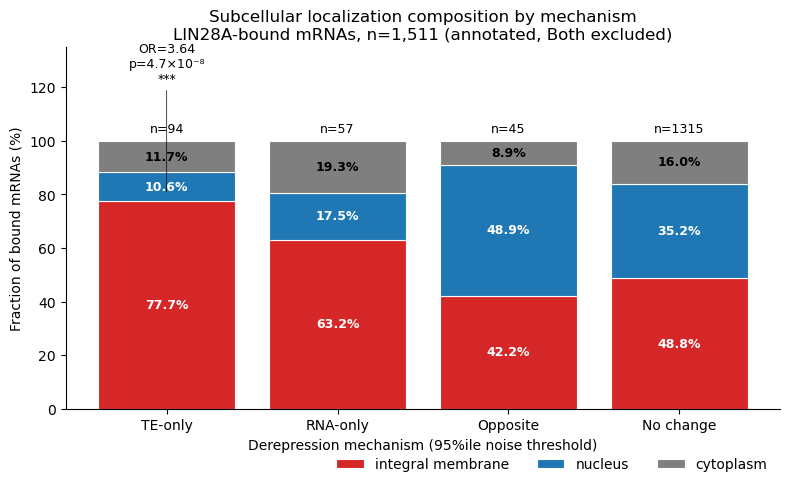

Saved: w5-figures/W5-1_localization_by_mechanism.png


In [26]:
# W5-1f: Stacked bar plot — mechanism별 localization composition
import matplotlib.pyplot as plt
import numpy as np
  
mech_order = ['TE-only', 'RNA-only', 'Opposite', 'No change']
loc_order  = ['integral membrane', 'nucleus', 'cytoplasm']  
colors = {'integral membrane': '#d62728',  # ER red (hypothesis target)
          'nucleus':           '#1f77b4',
          'cytoplasm':         '#7f7f7f'}

ctab_pct = (ctab.div(ctab.sum(axis=1), axis=0) * 100)

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(len(mech_order))
for cat in loc_order:
    vals = ctab_pct.loc[mech_order, cat].values
    bars = ax.bar(mech_order, vals, bottom=bottom, label=cat,
                    color=colors[cat], edgecolor='white', linewidth=0.8)
# 비율을 막대 안에 표시
    for i, (b, v) in enumerate(zip(bars, vals)):
        if v > 4:
            ax.text(i, bottom[i] + v/2, f'{v:.1f}%',
                    ha='center', va='center', fontsize=9,
                    color='white' if cat != 'cytoplasm' else 'black',
                    fontweight='bold')
    bottom += vals

# n 표시
for i, m in enumerate(mech_order):
    n = int(ctab.loc[m].sum())
    ax.text(i, 102, f'n={n}', ha='center', va='bottom', fontsize=9, color='black')

# significance annotation on TE-only (vs No change)
ax.annotate('OR=3.64\np=4.7×10⁻⁸\n***',
            xy=(0, 80), xytext=(0, 122),
            ha='center', fontsize=9,
            arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

ax.set_ylabel('Fraction of bound mRNAs (%)')
ax.set_xlabel('Derepression mechanism (95%ile noise threshold)')
ax.set_title('Subcellular localization composition by mechanism\nLIN28A-bound mRNAs, n=1,511 (annotated, Both excluded)')
ax.set_ylim(0, 135)
ax.legend(loc='upper right', bbox_to_anchor=(1.0, -0.10), ncol=3, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('w5-figures/W5-1_localization_by_mechanism.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: w5-figures/W5-1_localization_by_mechanism.png")

### W5-1 Robustness check (80%ile loose threshold)

  mechanism_80 컬럼으로 동일 분석 반복. TE-only × integral membrane enrichment 결론이 threshold 선택에 robust한지 검정.

In [27]:
# W5-1 robustness: 80% loose mechanism으로 W5-1c~e 반복

# Annotated + Both 제외 (mechanism_80 기준)
analysis80 = bound_loc[bound_loc['type'].notna() & (bound_loc['mechanism_80'] != 'Both')].copy()
print(f"Analysis set (80%ile): {len(analysis80)} bound mRNAs\n")

ctab80 = pd.crosstab(analysis80['mechanism_80'], analysis80['type']).reindex(
    index=mech_order, columns=loc_order)
print("=== Counts (80%ile loose) ===")
print(ctab80)
print(f"\nrow totals: {ctab80.sum(axis=1).to_dict()}\n")

ctab80_pct = (ctab80.div(ctab80.sum(axis=1), axis=0) * 100).round(1)
print("=== Row % ===")
print(ctab80_pct)
print()

# Chi-square
chi2_80, pval_80, dof_80, exp_80 = chi2_contingency(ctab80)
n80 = ctab80.values.sum()
cramers_v_80 = (chi2_80 / (n80 * (min(ctab80.shape) - 1))) ** 0.5
print(f"=== Chi-square (80%ile) ===")
print(f"  chi2={chi2_80:.2f}, p={pval_80:.3e}, df={dof_80}, Cramér's V={cramers_v_80:.3f}\n")

# Fisher exact vs No-change baseline
print("=== Fisher exact (integral membrane vs other, 80%ile) ===")
nc_ER80 = ctab80.loc['No change', 'integral membrane']
nc_other80 = ctab80.loc['No change', ['nucleus', 'cytoplasm']].sum()
results80 = []
for m in ['TE-only', 'RNA-only', 'Opposite']:
    m_ER = ctab80.loc[m, 'integral membrane']
    m_other = ctab80.loc[m, ['nucleus', 'cytoplasm']].sum()
    odds, p = fisher_exact([[m_ER, m_other], [nc_ER80, nc_other80]], alternative='two-sided')
    results80.append({'mechanism': m, 'OR': odds, 'p': p})
    print(f"  {m:10s}: {m_ER:3d} ER / {m_other:3d} other  |  OR={odds:.2f},  p={p:.3e}")

alpha_bonf = 0.05 / 3
print(f"\nBonferroni α = {alpha_bonf:.4f}")
for r in results80:
    sig = "✓ significant" if r['p'] < alpha_bonf else "✗ n.s."
    print(f"  {r['mechanism']:10s}: p={r['p']:.3e}  {sig}")

# 95%ile vs 80%ile 결과 나란히 비교
print("\n=== 95%ile vs 80%ile comparison ===")
summary = pd.DataFrame({
    '95%ile_OR':    [3.64, 1.80, 0.77],
    '95%ile_p':     [4.677e-08, 4.175e-02, 4.490e-01],
    '80%ile_OR':    [r['OR'] for r in results80],
    '80%ile_p':     [r['p']  for r in results80],
}, index=['TE-only', 'RNA-only', 'Opposite'])
print(summary.round(3))

Analysis set (80%ile): 1491 bound mRNAs

=== Counts (80%ile loose) ===
type          integral membrane  nucleus  cytoplasm
mechanism_80                                       
TE-only                     228       25         31
RNA-only                    101       38         21
Opposite                     77       98         28
No change                   348      344        152

row totals: {'TE-only': 284, 'RNA-only': 160, 'Opposite': 203, 'No change': 844}

=== Row % ===
type          integral membrane  nucleus  cytoplasm
mechanism_80                                       
TE-only                    80.3      8.8       10.9
RNA-only                   63.1     23.8       13.1
Opposite                   37.9     48.3       13.8
No change                  41.2     40.8       18.0

=== Chi-square (80%ile) ===
  chi2=165.53, p=3.996e-33, df=6, Cramér's V=0.236

=== Fisher exact (integral membrane vs other, 80%ile) ===
  TE-only   : 228 ER /  56 other  |  OR=5.80,  p=1.828e-31
  RNA-only

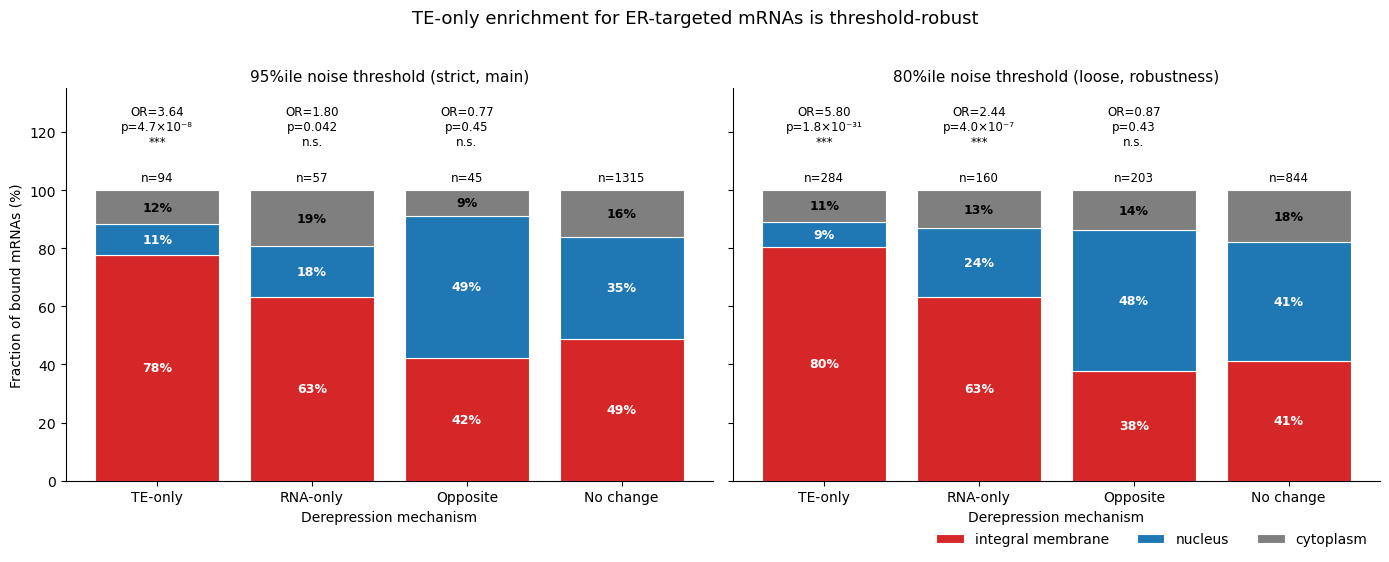

Saved: w5-figures/W5-1_localization_robustness.png


In [28]:
# W5-1g: 95% vs 80% threshold side-by-side comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

ctab_pct_80 = (ctab80.div(ctab80.sum(axis=1), axis=0) * 100)

panels = [
    (axes[0], ctab,    ctab_pct,    '95%ile noise threshold (strict, main)',
    [(0, 'OR=3.64', 'p=4.7×10⁻⁸', '***'),
     (1, 'OR=1.80', 'p=0.042',    'n.s.'),
     (2, 'OR=0.77', 'p=0.45',     'n.s.')]),
    (axes[1], ctab80,  ctab_pct_80, '80%ile noise threshold (loose, robustness)',
     [(0, 'OR=5.80', 'p=1.8×10⁻³¹','***'),
      (1, 'OR=2.44', 'p=4.0×10⁻⁷', '***'),
      (2, 'OR=0.87', 'p=0.43',     'n.s.')]),
]

for ax, ct, ct_pct, title, sig_info in panels:
    bottom = np.zeros(len(mech_order))
    for cat in loc_order:
        vals = ct_pct.loc[mech_order, cat].values
        bars = ax.bar(mech_order, vals, bottom=bottom, label=cat,
                        color=colors[cat], edgecolor='white', linewidth=0.8)
        for i, (b, v) in enumerate(zip(bars, vals)):
            if v > 4:
                ax.text(i, bottom[i] + v/2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=9,
                        color='white' if cat != 'cytoplasm' else 'black',
                        fontweight='bold')
        bottom += vals

    # n labels
    for i, m in enumerate(mech_order):
        n = int(ct.loc[m].sum())
        ax.text(i, 102, f'n={n}', ha='center', va='bottom', fontsize=8.5, color='black')

    # significance annotation
    for idx, or_text, p_text, stars in sig_info:
        ax.text(idx, 122, f'{or_text}\n{p_text}\n{stars}',
                ha='center', va='center', fontsize=8.5)

    ax.set_xlabel('Derepression mechanism')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(0, 135)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Fraction of bound mRNAs (%)')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.0, -0.10),
                ncol=3, frameon=False)

fig.suptitle('TE-only enrichment for ER-targeted mRNAs is threshold-robust',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('w5-figures/W5-1_localization_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: w5-figures/W5-1_localization_robustness.png")